In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

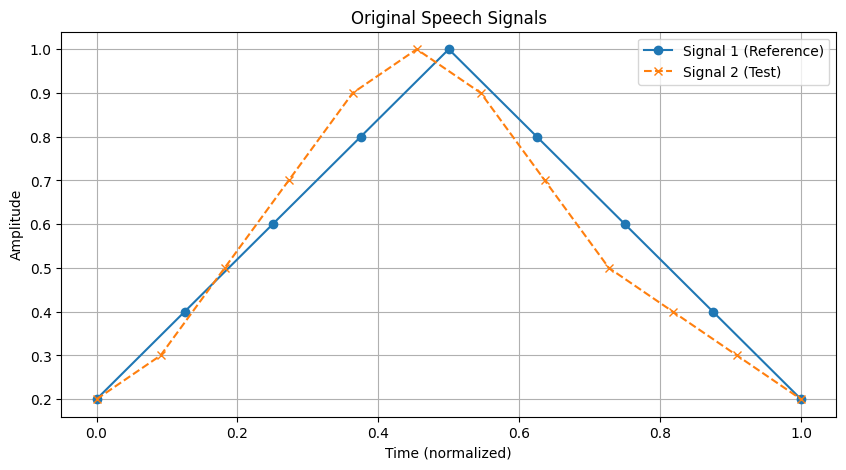

In [2]:
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])   # Reference
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])  # Test

t1 = np.linspace(0, 1, len(signal1))
t2 = np.linspace(0, 1, len(signal2))

plt.figure(figsize=(10,5))
plt.plot(t1, signal1, 'o-', label='Signal 1 (Reference)')
plt.plot(t2, signal2, 'x--', label='Signal 2 (Test)')
plt.title('Original Speech Signals')
plt.xlabel('Time (normalized)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

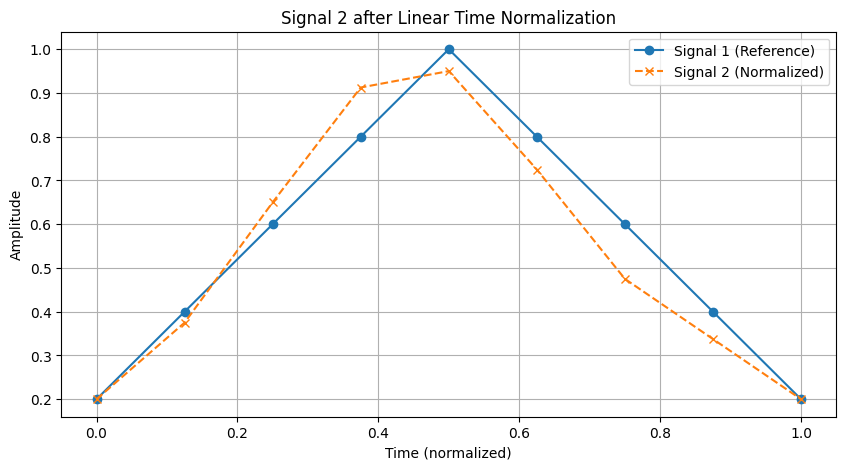

In [3]:
interp_func = interp1d(t2, signal2, kind='linear')
signal2_normalized = interp_func(t1)

plt.figure(figsize=(10,5))
plt.plot(t1, signal1, 'o-', label='Signal 1 (Reference)')
plt.plot(t1, signal2_normalized, 'x--', label='Signal 2 (Normalized)')
plt.title('Signal 2 after Linear Time Normalization')
plt.xlabel('Time (normalized)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Compute sample-wise difference (alignment error)
alignment_error = np.abs(signal1 - signal2_normalized)

# Print alignment values
for i, (s1, s2n, err) in enumerate(zip(signal1, signal2_normalized, alignment_error)):
    print(f"Sample {i+1}: Signal1 = {s1:.2f}, Signal2_norm = {s2n:.2f}, |Error| = {err:.3f}")


Sample 1: Signal1 = 0.20, Signal2_norm = 0.20, |Error| = 0.000
Sample 2: Signal1 = 0.40, Signal2_norm = 0.38, |Error| = 0.025
Sample 3: Signal1 = 0.60, Signal2_norm = 0.65, |Error| = 0.050
Sample 4: Signal1 = 0.80, Signal2_norm = 0.91, |Error| = 0.112
Sample 5: Signal1 = 1.00, Signal2_norm = 0.95, |Error| = 0.050
Sample 6: Signal1 = 0.80, Signal2_norm = 0.72, |Error| = 0.075
Sample 7: Signal1 = 0.60, Signal2_norm = 0.48, |Error| = 0.125
Sample 8: Signal1 = 0.40, Signal2_norm = 0.34, |Error| = 0.062
Sample 9: Signal1 = 0.20, Signal2_norm = 0.20, |Error| = 0.000


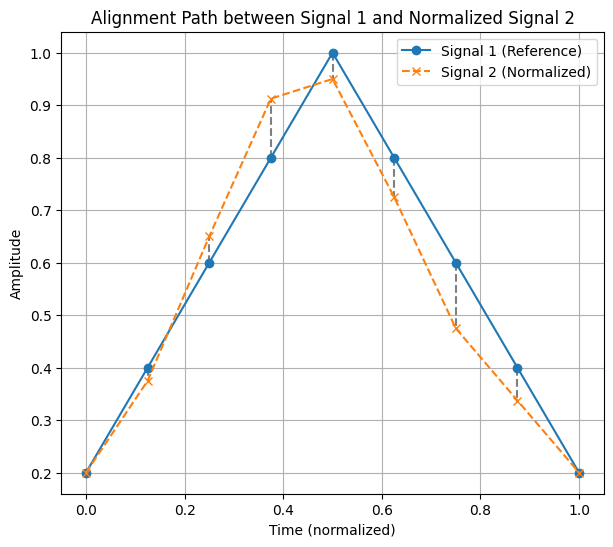

In [5]:
plt.figure(figsize=(7,6))
for i in range(len(signal1)):
    plt.plot([t1[i], t1[i]], [signal1[i], signal2_normalized[i]], 'k--', alpha=0.5)

plt.plot(t1, signal1, 'o-', label='Signal 1 (Reference)')
plt.plot(t1, signal2_normalized, 'x--', label='Signal 2 (Normalized)')
plt.title('Alignment Path between Signal 1 and Normalized Signal 2')
plt.xlabel('Time (normalized)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()



### Inference:
Linear Time Normalization (LTN) adjusts the time axis of the slower signal (Signal 2)
so that both signals have the same number of samples.

After normalization:
- The two speech signals align closely in time.
- The temporal patterns (rises and falls in amplitude) now match.
- This makes it possible to compare or match the two waveforms accurately.

Hence, LTN effectively compensates for differences in speaking speed
and ensures that corresponding parts of the same word align properly in time.


